In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import anndata as an
import scanpy as sc

sc.settings.verbosity = 2

# Load data

* Cluster each time point independently
* See how clusters align with scANVI predictions --> do any clusters point towards D48-like cells?
* Do marker genes make sense?
* Identify the most "changing" clusters

In [6]:
%%time

# h5ad built in Hematokytos/anndatas/timeseries_reprogram.ipynb
fpath = "/nfs/turbo/umms-indikar/shared/projects/parse/anndatas/parse_processed_v1.h5ad"

pdata = sc.read_h5ad(fpath)
pdata.obs = pdata.obs.set_index('bc_wells')
pdata.obs['batch'] = 'parse'

pdata

CPU times: user 178 ms, sys: 355 ms, total: 533 ms
Wall time: 1.44 s


AnnData object with n_obs × n_vars = 6174 × 18695
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_well', 'bc2_well', 'bc3_well', 'condition', 'condition_group', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'condition_group_wTD', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'batch'
    var: 'gene_id', 'gene_name', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_st

## Get scANVI predictions

In [7]:
%%time
# h5ad built in Hematokytos/figure3/timeseries_embedding.ipynb
fpath = "/nfs/turbo/umms-indikar/shared/projects/parse/anndatas/scfib_hsc_parse_integration_wFA.h5ad"

fdata = sc.read_h5ad(fpath)
fdata

t = 0.85

fdata.obs['prediction'] = 'ambiguous'

fdata.obs.loc[fdata.obs['prob_D48_like_cc_covar'] > t, 'prediction'] = 'D48_like'
fdata.obs.loc[fdata.obs['prob_fibroblast_control_cc_covar'] > t, 'prediction'] = 'Fib_like'

df = fdata.obs[['prediction']].copy()
print(df.shape)
df.head()

# merge with parse data 
df1 = df[df.index.isin(pdata.obs_names)].copy()
print(df1.shape)
df1.head()

pdata.obs = pdata.obs.join(df1)
pdata

(21491, 1)
(6174, 1)
CPU times: user 351 ms, sys: 2.37 s, total: 2.72 s
Wall time: 5.67 s


AnnData object with n_obs × n_vars = 6174 × 18695
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_well', 'bc2_well', 'bc3_well', 'condition', 'condition_group', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'condition_group_wTD', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'batch', 'prediction'
    var: 'gene_id', 'gene_name', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    un

# Clusters

## HVGs per subgroup

Working D7...
filtered out 68 genes that are detected in less than 1 cells
extracting highly variable genes
computing PCA
    with n_comps=30
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:00)
computing UMAP
    finished (0:00:02)
running Leiden clustering
    finished (0:00:00)
ranking genes


... storing 'batch' as categorical
... storing 'prediction' as categorical


    finished (0:00:01)


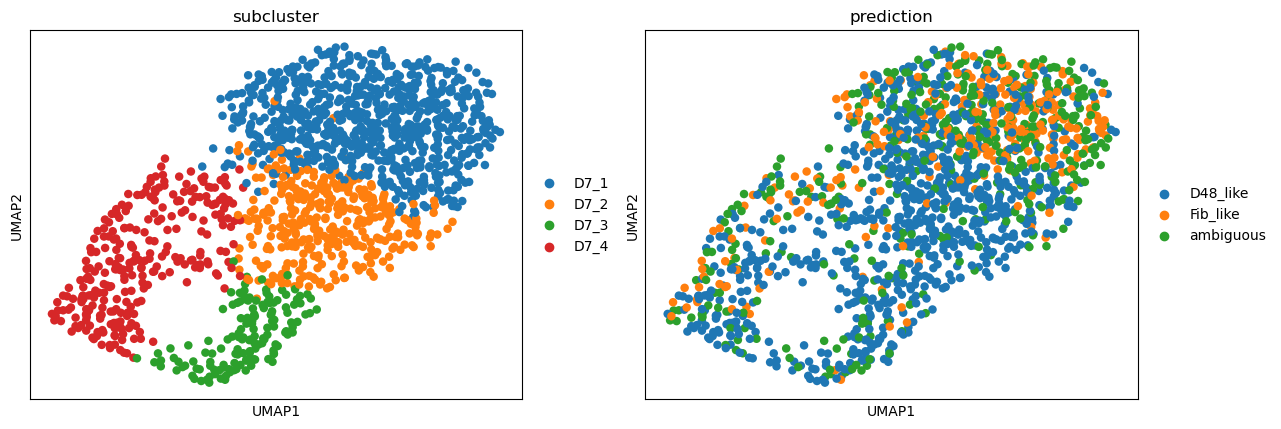

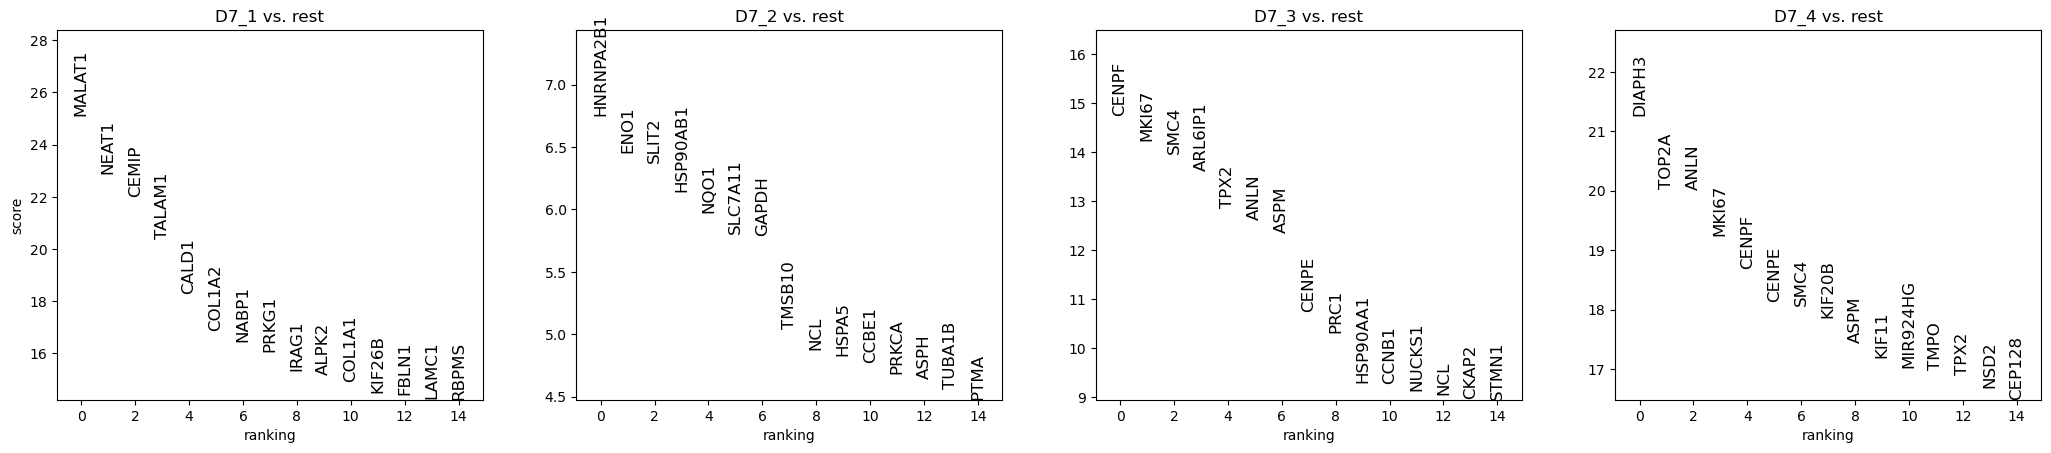

Working D14...
filtered out 121 genes that are detected in less than 1 cells
extracting highly variable genes
computing PCA
    with n_comps=30
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:00)
computing UMAP
    finished (0:00:03)
running Leiden clustering
    finished (0:00:00)
ranking genes


... storing 'batch' as categorical
... storing 'prediction' as categorical


    finished (0:00:01)


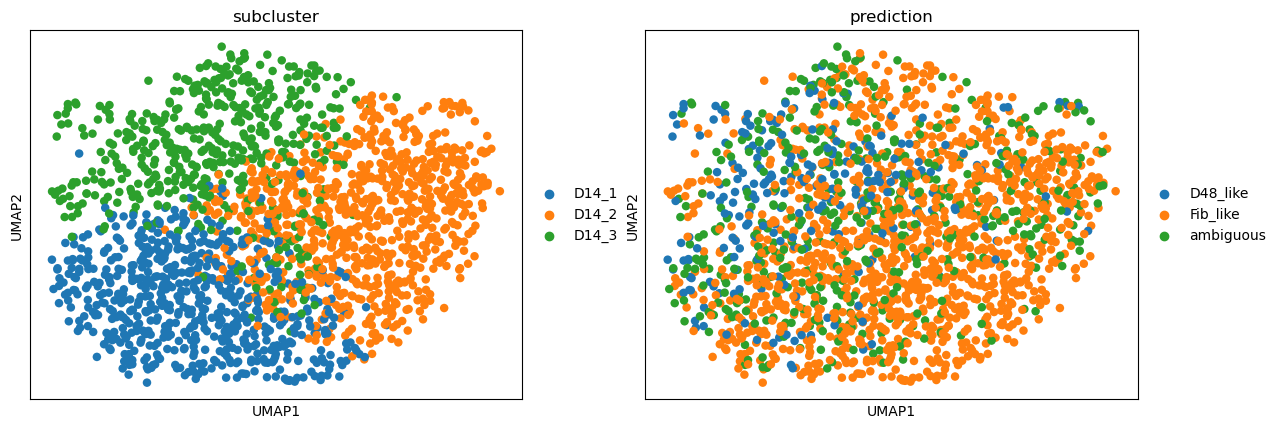

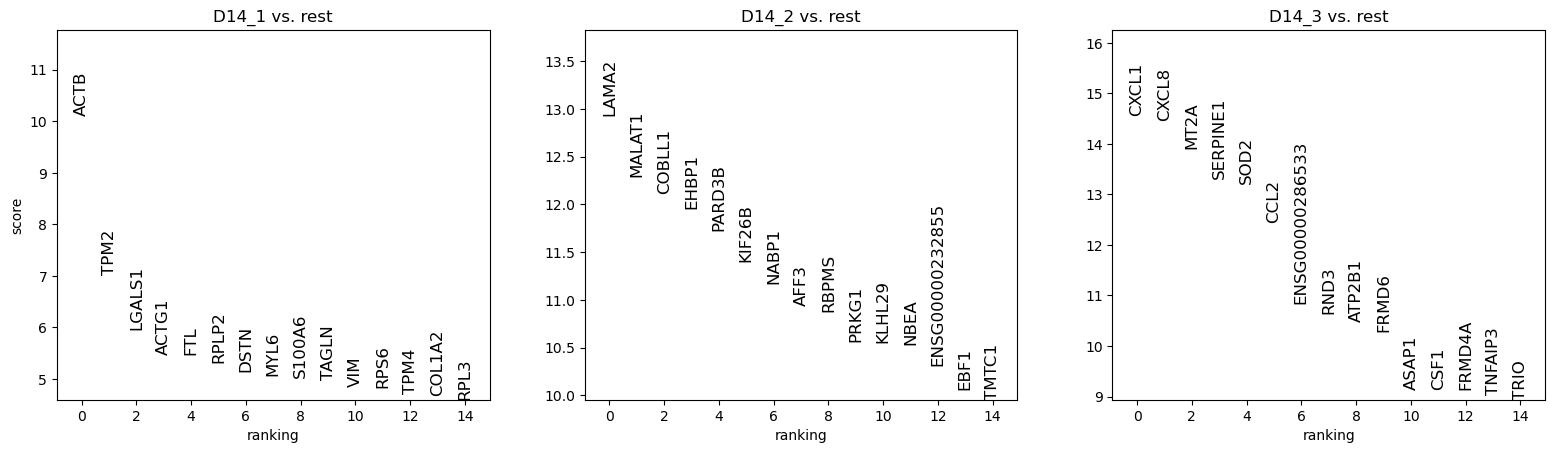

Working D21...
filtered out 181 genes that are detected in less than 1 cells
extracting highly variable genes
computing PCA
    with n_comps=30
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:00)
computing UMAP
    finished (0:00:02)
running Leiden clustering
    finished (0:00:00)
ranking genes


... storing 'batch' as categorical
... storing 'prediction' as categorical


    finished (0:00:01)


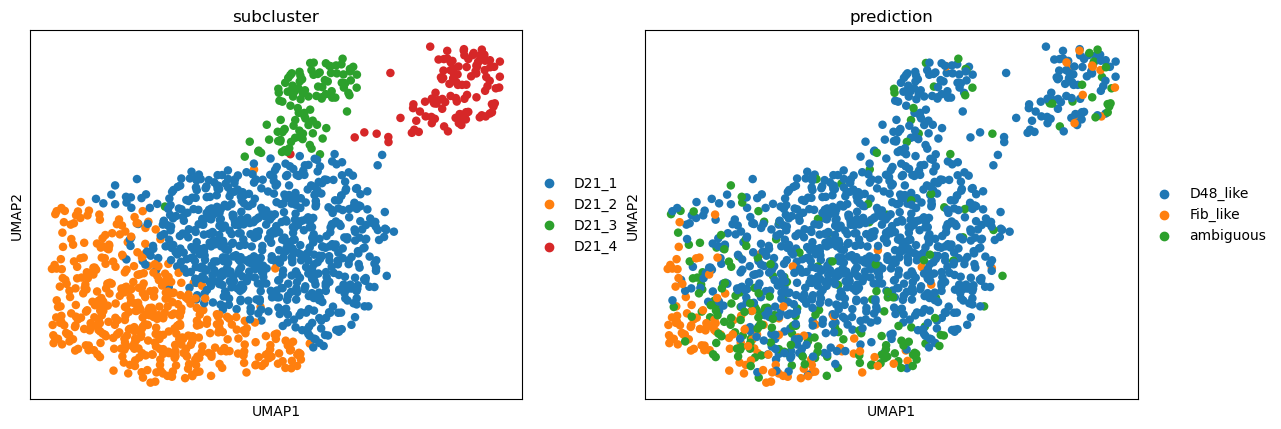

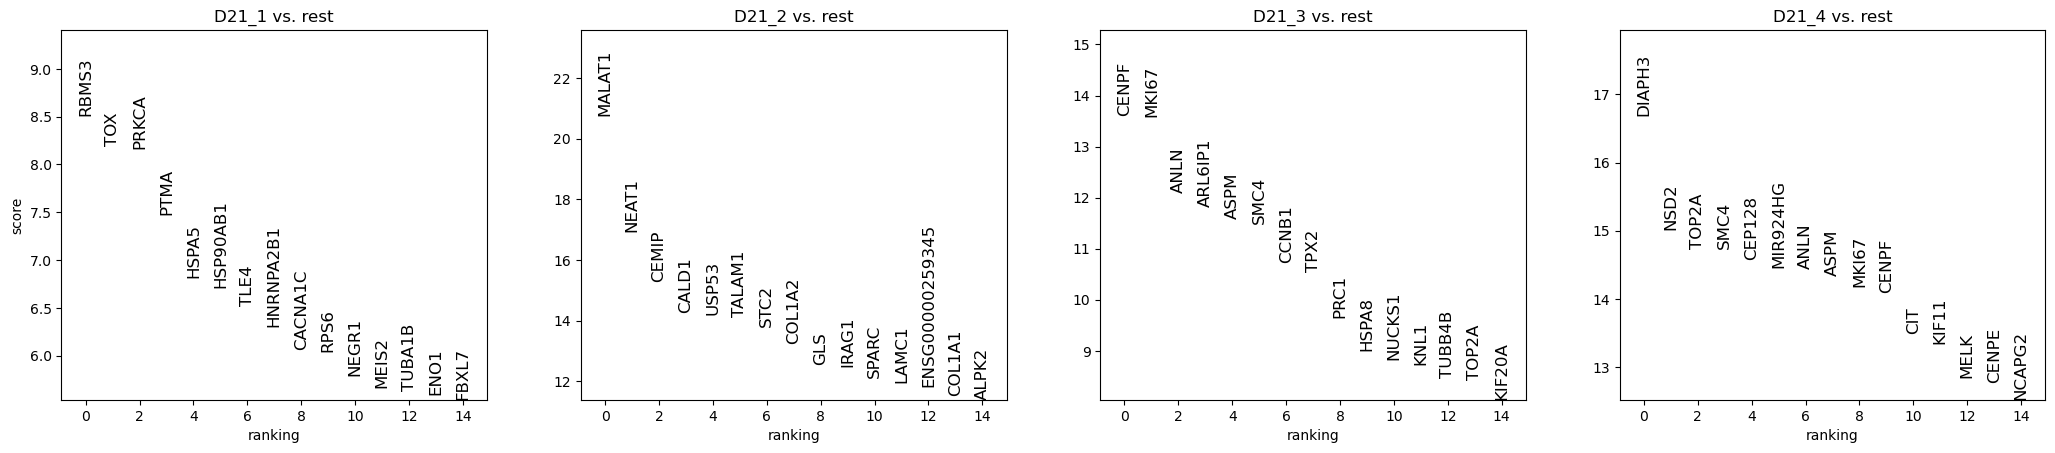

CPU times: user 16.5 s, sys: 470 ms, total: 17 s
Wall time: 17.2 s


In [8]:
%%time
adata = pdata.copy()

res = 0.4
n_neighbors = 10

adata7 = adata[adata.obs['condition_group'] == 'D7', :].copy()
adata14 = adata[adata.obs['condition_group'] == 'D14', :].copy()
adata21 = adata[adata.obs['condition_group'] == 'D21', :].copy()

def subgroup_cluster(adata, group, n_neighbors=10, leiden_res=0.3, n_pcs=30):
    print(f'Working {group}...')
    
    sc.pp.filter_genes(adata, min_cells=1)   # drop genes with zero expression in this subset
    
    adata.X = adata.layers['raw_counts']
    sc.pp.highly_variable_genes(adata, flavor='seurat_v3') # select HVGs
    
    adata.X = adata.layers['log_norm']

    sc.pp.pca(adata, n_comps=n_pcs, mask_var=adata.var['highly_variable'])
    sc.pp.neighbors(adata, n_neighbors=n_neighbors)
    sc.tl.umap(adata)
    sc.tl.leiden(adata, resolution=leiden_res, flavor='igraph', n_iterations=100) # 100 is rapids default
  
    adata.obs['cluster_str'] = adata.obs['leiden'].apply(lambda x: f"{str(int(x) + 1)}")
    adata.obs['subcluster'] = adata.obs['leiden'].apply(lambda x: f"{group}_{str(int(x) + 1)}")

    sc.tl.rank_genes_groups(adata, 'subcluster', method='wilcoxon', layer='log_norm', use_raw=False)

    return adata

plt.rcdefaults()

adata7 = subgroup_cluster(adata7, group='D7', leiden_res=res)
sc.pl.umap(adata7, color=['subcluster', 'prediction'], size=150)
sc.pl.rank_genes_groups(adata7, n_genes=15, sharey=False, fontsize=12)

adata14 = subgroup_cluster(adata14, group='D14', leiden_res=res)
sc.pl.umap(adata14, color=['subcluster', 'prediction'], size=150)
sc.pl.rank_genes_groups(adata14, n_genes=15, sharey=False, fontsize=12)

adata21 = subgroup_cluster(adata21, group='D21', leiden_res=res)
sc.pl.umap(adata21, color=['subcluster', 'prediction'], size=150)
sc.pl.rank_genes_groups(adata21, n_genes=15, sharey=False, fontsize=12)

# D7 plots

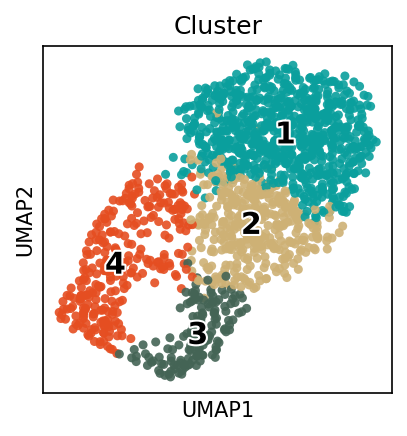

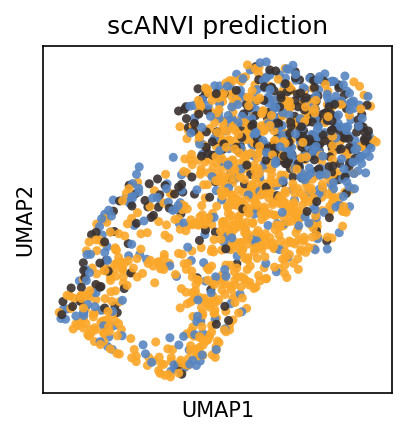

In [9]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 3, 3

pred_palette = {
    'D48_like': '#FBA72A',
    'Fib_like': '#39312F',
    'ambiguous': '#5785C1',#'#D3DDDC',
}

clust_palette = {
    '1' : '#0A9F9D',
    '2' : '#CEB175',
    '3' : '#446455',#'#446455',
    '4' : '#E54E21',
}
    
    
sc.pl.umap(
    adata7,
    color=['cluster_str'],
    size=75,
    alpha=0.9,
    legend_loc='on data',
    legend_fontoutline=2,
    legend_fontweight='bold',
    legend_fontsize='x-large',
    title='Cluster',
    palette=clust_palette,
)

sc.pl.umap(
    adata7,
    color=['prediction'],
    size=75,
    alpha=0.9,
    legend_fontsize='small',
    legend_loc='none',
    title='scANVI prediction',
    palette=pred_palette,
)

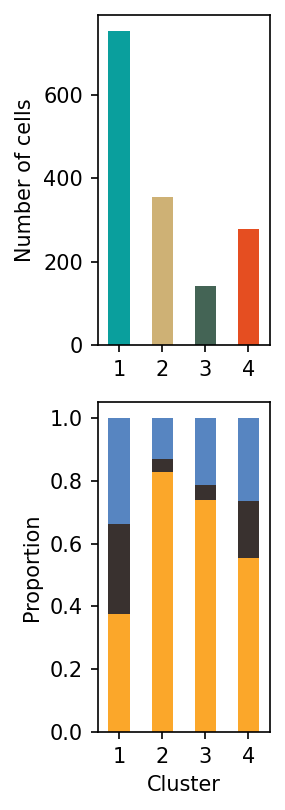

In [10]:
ct = pd.crosstab(adata7.obs['cluster_str'], adata7.obs['prediction'])
ct_norm = ct.div(ct.sum(axis=1), axis=0)

cluster_order = ['1', '2', '3', '4']
ct_norm = ct_norm.reindex(cluster_order)

fig, axes = plt.subplots(2, 1, figsize=(2, 5.5), height_ratios=[1, 1])

ct_norm.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[pred_palette[p] for p in ct_norm.columns],
    legend=False,
)

axes[1].set_ylabel("Proportion")
axes[1].set_xlabel("Cluster")

cell_counts = ct.sum(axis=1).reindex(cluster_order)

cell_counts.plot(
    kind='bar',
    ax=axes[0],
    color=[clust_palette[c] for c in cell_counts.index],
    legend=False,
)

axes[0].set_ylabel("Number of cells")
axes[0].set_xlabel("")

axes[0].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# D14 plots

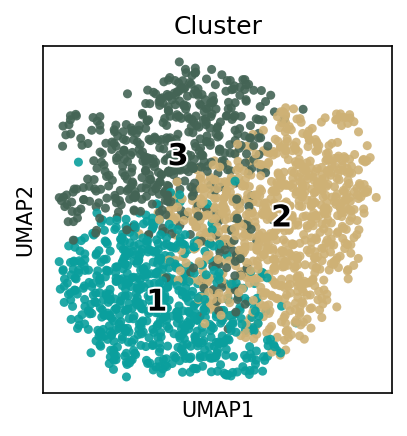

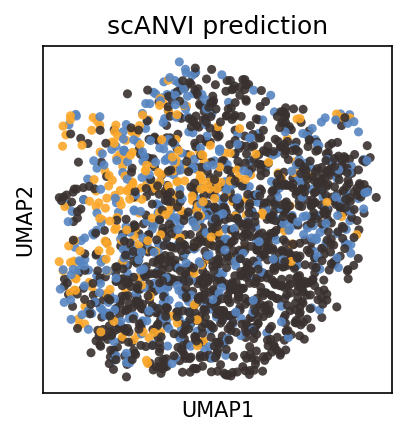

In [13]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 3, 3

pred_palette = {
    'D48_like': '#FBA72A',
    'Fib_like': '#39312F',
    'ambiguous': '#5785C1',#'#D3DDDC',
}

clust_palette = {
    '1' : '#0A9F9D',
    '2' : '#CEB175',
    '3' : '#446455',#'#446455',
    '4' : '#E54E21',
}
    
    
sc.pl.umap(
    adata14,
    color=['cluster_str'],
    size=75,
    alpha=0.9,
    legend_loc='on data',
    legend_fontoutline=2,
    legend_fontweight='bold',
    legend_fontsize='x-large',
    title='Cluster',
    palette=clust_palette,
)

sc.pl.umap(
    adata14,
    color=['prediction'],
    size=75,
    alpha=0.9,
    legend_fontsize='small',
    legend_loc='none',
    title='scANVI prediction',
    palette=pred_palette,
)

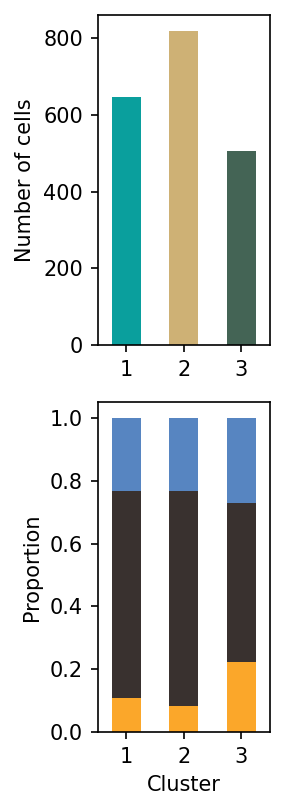

In [15]:
ct = pd.crosstab(adata14.obs['cluster_str'], adata14.obs['prediction'])
ct_norm = ct.div(ct.sum(axis=1), axis=0)

cluster_order = ['1', '2', '3']#, '4']
ct_norm = ct_norm.reindex(cluster_order)

fig, axes = plt.subplots(2, 1, figsize=(2, 5.5), height_ratios=[1, 1])

ct_norm.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[pred_palette[p] for p in ct_norm.columns],
    legend=False,
)

axes[1].set_ylabel("Proportion")
axes[1].set_xlabel("Cluster")

cell_counts = ct.sum(axis=1).reindex(cluster_order)

cell_counts.plot(
    kind='bar',
    ax=axes[0],
    color=[clust_palette[c] for c in cell_counts.index],
    legend=False,
)

axes[0].set_ylabel("Number of cells")
axes[0].set_xlabel("")

axes[0].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# D21 plots

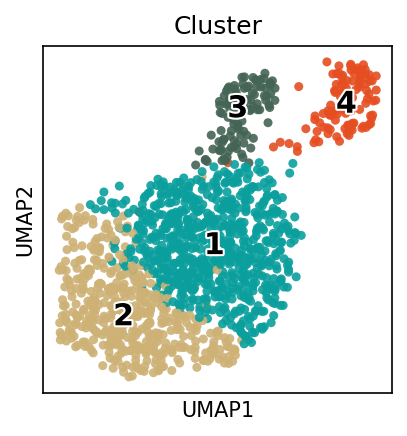

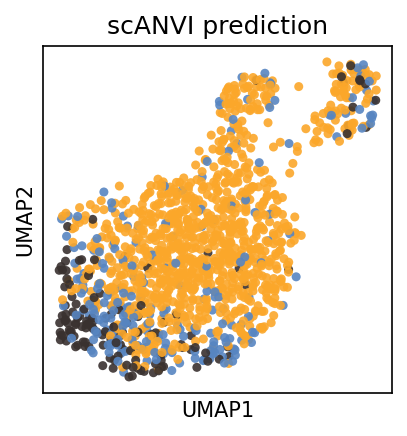

In [11]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 3, 3

pred_palette = {
    'D48_like': '#FBA72A',
    'Fib_like': '#39312F',
    'ambiguous': '#5785C1',#'#D3DDDC',
}

clust_palette = {
    '1' : '#0A9F9D',
    '2' : '#CEB175',
    '3' : '#446455',#'#446455',
    '4' : '#E54E21',
}
    
    
sc.pl.umap(
    adata21,
    color=['cluster_str'],
    size=75,
    alpha=0.9,
    legend_loc='on data',
    legend_fontoutline=2,
    legend_fontweight='bold',
    legend_fontsize='x-large',
    title='Cluster',
    palette=clust_palette,
)

sc.pl.umap(
    adata21,
    color=['prediction'],
    size=75,
    alpha=0.9,
    legend_fontsize='small',
    legend_loc='none',
    title='scANVI prediction',
    palette=pred_palette,
)

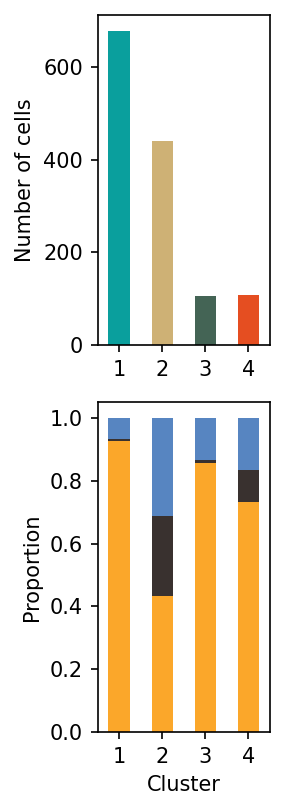

In [12]:
ct = pd.crosstab(adata21.obs['cluster_str'], adata21.obs['prediction'])
ct_norm = ct.div(ct.sum(axis=1), axis=0)

cluster_order = ['1', '2', '3', '4']
ct_norm = ct_norm.reindex(cluster_order)

fig, axes = plt.subplots(2, 1, figsize=(2, 5.5), height_ratios=[1, 1])

ct_norm.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[pred_palette[p] for p in ct_norm.columns],
    legend=False,
)

axes[1].set_ylabel("Proportion")
axes[1].set_xlabel("Cluster")

cell_counts = ct.sum(axis=1).reindex(cluster_order)

cell_counts.plot(
    kind='bar',
    ax=axes[0],
    color=[clust_palette[c] for c in cell_counts.index],
    legend=False,
)

axes[0].set_ylabel("Number of cells")
axes[0].set_xlabel("")

axes[0].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# DEG plots

In [16]:
def plot_rank_genes_scores_custom(
    adata,
    groups=None,
    n_genes=10,
    cluster_color=None,
    ncols=4,
    figsize_per_panel=(2.5, 2.5),
    fontsize=8,
    title_fontsize=10,
    point_size=30,
    line=True,
    rotate_gene_labels=45,
    max_pval_adj=None,
    min_logfc=None,
    use_abs_logfc_filter=False,
    rank_by='scores',
    rank_by_abs=False,
    rank_ascending=False,
    y_col='scores',
    show=True
):
    """
    Custom rank_genes_groups plot.

    Plots:
        x-axis: rank after filtering
        y-axis: selected value, default = scores
        labels: gene names

    Filtering happens before ranks are assigned.

    Parameters
    ----------
    adata : AnnData
        AnnData object.
    key : str
        Key in adata.uns containing rank_genes_groups results.
    groups : list or None
        Groups/clusters to plot. If None, all groups are plotted.
    n_genes : int
        Number of genes to plot per group after filtering and ranking.
    cluster_color : dict or None
        Dictionary mapping cluster/group names to colors.
    max_pval_adj : float or None
        Keep genes with pvals_adj <= max_pval_adj.
    min_logfc : float or None
        Keep genes with logfoldchanges >= min_logfc unless use_abs_logfc_filter=True.
    use_abs_logfc_filter : bool
        If True, filter using abs(logfoldchanges) >= min_logfc.
    rank_by : str
        Column used to compute rank after filtering.
        Common options: 'scores', 'logfoldchanges', 'pvals_adj'.
    rank_by_abs : bool
        If True, rank by abs(rank_by).
        Useful for ranking by absolute logFC.
    rank_ascending : bool
        Sort direction for ranking.
        False means largest values are rank 1.
    y_col : str
        Column to plot on y-axis.
        Usually 'scores' or 'logfoldchanges'.
    """

    rank_df = sc.get.rank_genes_groups_df(
        adata,
        group=None,
    )

    # remove mito/ribo/unnamed
    rank_df = rank_df[~rank_df['names'].str.startswith(('MT-', 'RP', 'ENSG'))].copy()
    
    rank_df['group'] = rank_df['group'].astype(str)

    if groups is None:
        groups = rank_df['group'].unique().tolist()
    else:
        groups = [str(g) for g in groups]

    required_cols = {'group', 'names', rank_by, y_col}

    if max_pval_adj is not None:
        required_cols.add('pvals_adj')

    if min_logfc is not None:
        required_cols.add('logfoldchanges')

    missing_cols = required_cols - set(rank_df.columns)
    if len(missing_cols) > 0:
        raise ValueError(f"Missing columns in rank_genes_groups result: {missing_cols}")

    n_groups = len(groups)
    nrows = int(np.ceil(n_groups / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(
            figsize_per_panel[0] * ncols,
            figsize_per_panel[1] * nrows
        ),
        squeeze=False
    )

    axes = axes.flatten()

    for ax, group in zip(axes, groups):
        df_group = rank_df[rank_df['group'] == group].copy()

        # -----------------------------
        # Filter BEFORE ranking
        # -----------------------------

        if max_pval_adj is not None:
            df_group = df_group[df_group['pvals_adj'] < max_pval_adj]

        if min_logfc is not None:
            if use_abs_logfc_filter:
                df_group = df_group[
                    df_group['logfoldchanges'].abs() >= min_logfc
                ]
            else:
                df_group = df_group[
                    df_group['logfoldchanges'] >= min_logfc
                ]

        # -----------------------------
        # Rank AFTER filtering
        # -----------------------------

        if rank_by_abs:
            df_group['_rank_value'] = df_group[rank_by].abs()
        else:
            df_group['_rank_value'] = df_group[rank_by]

        df_group = df_group.sort_values(
            '_rank_value',
            ascending=rank_ascending
        )

        df_group = df_group.head(n_genes).copy()

        # Assign new rank after filtering and sorting
        df_group['rank'] = np.arange(1, len(df_group) + 1)

        if cluster_color is not None:
            color = cluster_color.get(group, '#777777')
        else:
            color = '#777777'

        if len(df_group) == 0:
            ax.text(
                0.5, 0.5,
                "No genes pass filters",
                ha='center',
                va='center',
                transform=ax.transAxes,
                fontsize=fontsize
            )
            ax.set_title(f"Cluster {group}", fontsize=title_fontsize)
            ax.set_xlabel("Rank", fontsize=fontsize)
            ax.set_ylabel(y_col, fontsize=fontsize)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            continue

        if line:
            ax.plot(
                df_group['rank'],
                df_group[y_col],
                color=color,
                linewidth=1,
                alpha=0.7
            )

        ax.scatter(
            df_group['rank'],
            df_group[y_col],
            color=color,
            s=point_size
        )

        for _, row in df_group.iterrows():
            ax.text(
                row['rank'],
                row[y_col],
                row['names'],
                fontsize='large',
                rotation=rotate_gene_labels,
                ha='center',
                va='center'
            )

        ax.set_title(f"Cluster {group.split('_')[1]}", fontsize='large')
        ax.set_xlabel(f"Rank", fontsize='medium')
        ax.set_ylabel(y_col.capitalize(), fontsize='medium')

        # ax.set_xticks(df_group['rank'])
        ax.tick_params(axis='both', labelsize='small')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.margins(y=0.25)

    for ax in axes[n_groups:]:
        ax.axis('off')

    plt.tight_layout()

    if show:
        plt.show()

    return fig, axes

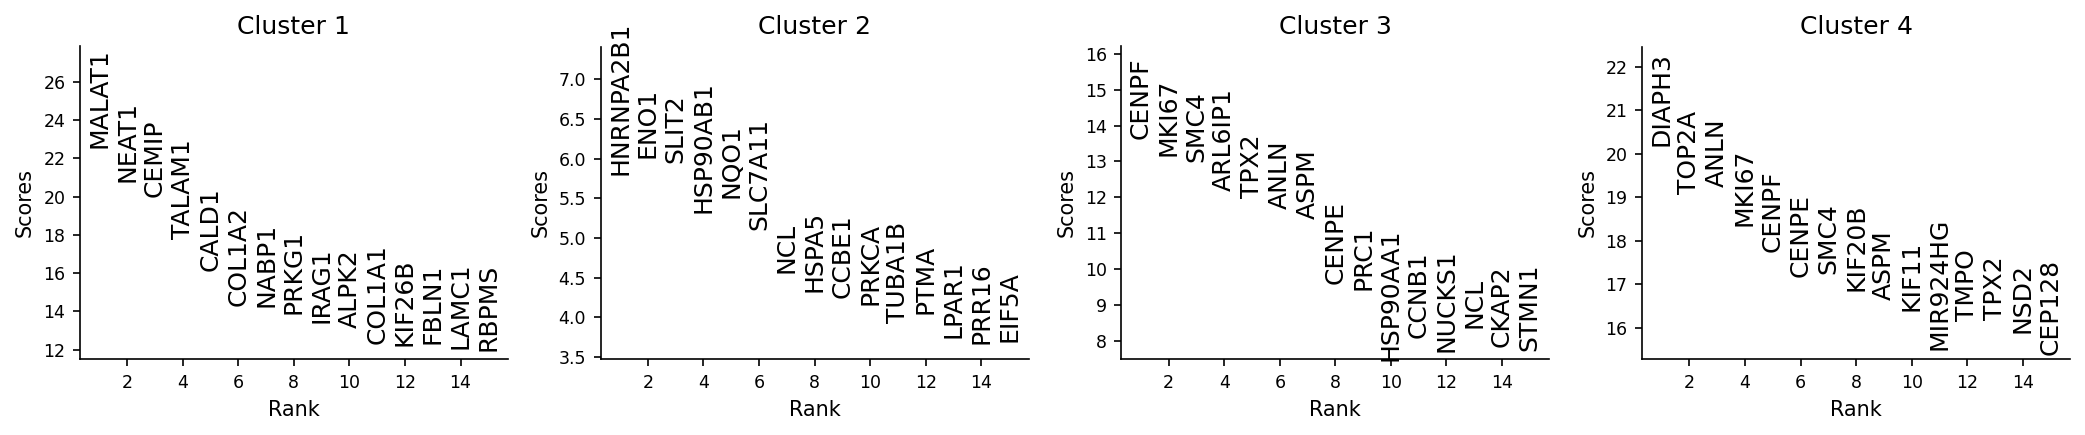

In [18]:
fig, axes = plot_rank_genes_scores_custom(
    adata7,
    groups=None,
    n_genes=15,
    cluster_color=clust_palette,
    ncols=4,
    figsize_per_panel=(3.5, 3),
    max_pval_adj=0.05,
    min_logfc=0.25,
    rank_by='scores',
    y_col='scores',
    rotate_gene_labels=90,
    point_size=0,
    line=False,
)

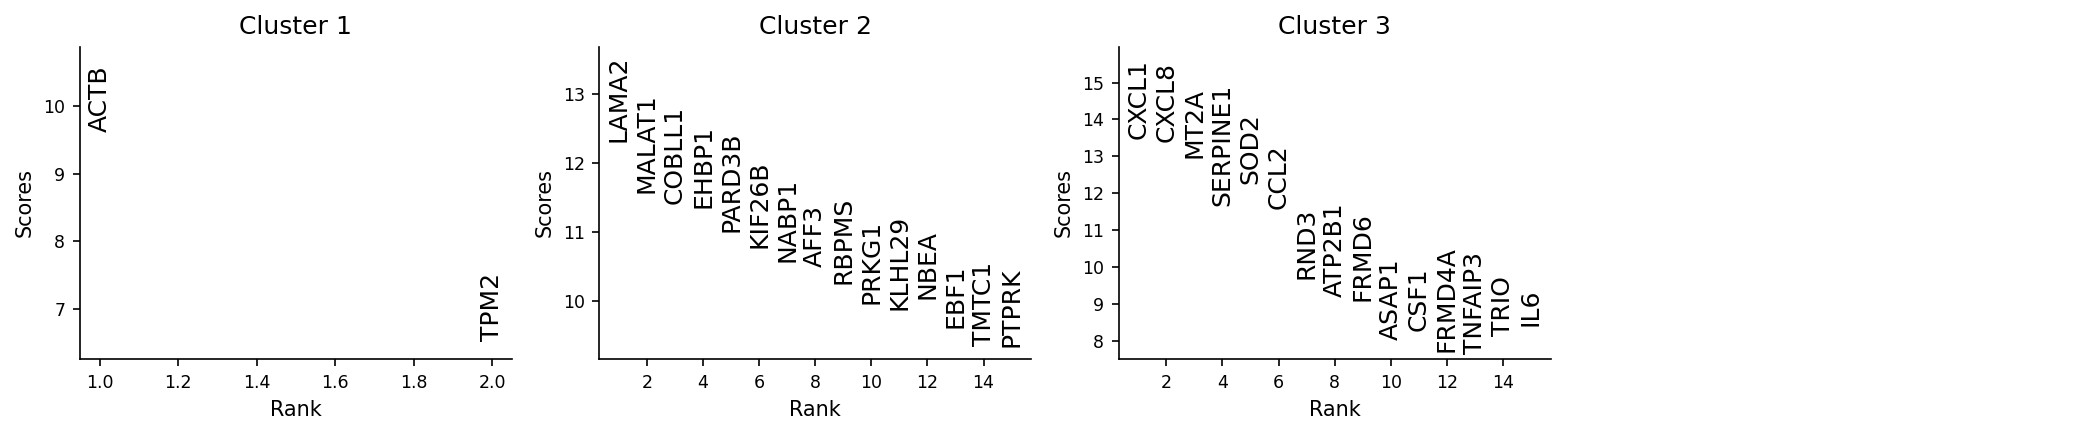

In [19]:
fig, axes = plot_rank_genes_scores_custom(
    adata14,
    groups=None,
    n_genes=15,
    cluster_color=clust_palette,
    ncols=4,
    figsize_per_panel=(3.5, 3),
    max_pval_adj=0.05,
    min_logfc=0.25,
    rank_by='scores',
    y_col='scores',
    rotate_gene_labels=90,
    point_size=0,
    line=False,
)

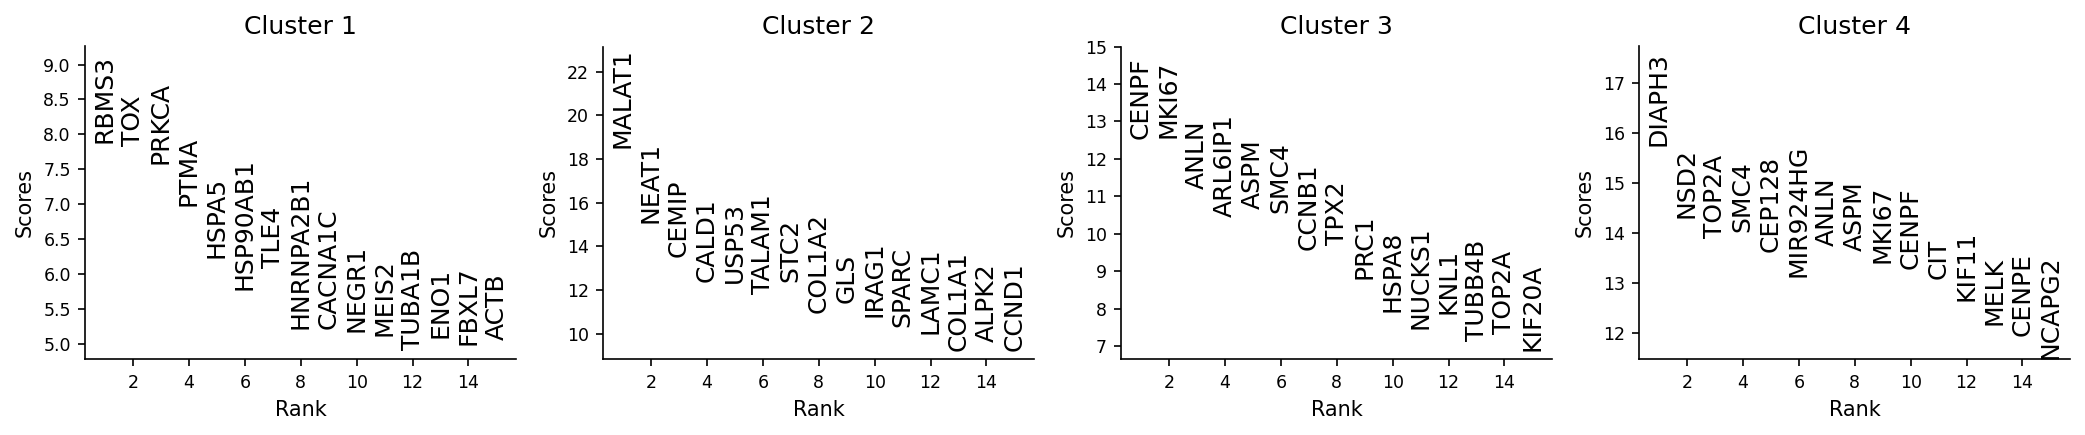

In [17]:
fig, axes = plot_rank_genes_scores_custom(
    adata21,
    groups=None,
    n_genes=15,
    cluster_color=clust_palette,
    ncols=4,
    figsize_per_panel=(3.5, 3),
    max_pval_adj=0.05,
    min_logfc=0.25,
    rank_by='scores',
    y_col='scores',
    rotate_gene_labels=90,
    point_size=0,
    line=False,
)

# Write clusters to dataframe

In [20]:
d7 = adata7.obs[['subcluster']].copy()
print(f'{d7.shape=}')
d7.head()

d14 = adata14.obs[['subcluster']].copy()
print(f'{d14.shape=}')

d21 = adata21.obs[['subcluster']].copy()
print(f'{d21.shape=}')


clust_df = pd.concat([d7, d14, d21])
print(f'{clust_df.shape=}')

# write out
clust_df.to_csv("../resources/timeseries_clusters_by_day.csv")

clust_df.head()

d7.shape=(1529, 1)
d14.shape=(1973, 1)
d21.shape=(1331, 1)
clust_df.shape=(4833, 1)


,subcluster
bc_wells,
04_01_03,D7_1
04_01_10,D7_1
04_01_16,D7_1
04_01_21,D7_2
04_01_27,D7_1


# Explore DEGs

## Load markers

In [21]:
# marker genes
fpath = "../resources/clean_marker_genes.csv"

mdf = pd.read_csv(fpath)
print(mdf.shape)
display(mdf.head())

endo_genes = mdf[mdf['cell_type'].isin(['endothelial_cells'])]['gene_name'].unique()
hsc_genes = mdf[mdf['cell_type'].isin(['hematopoietic_stem_cells', 'bone_marrow-hematopoietic_stem_cell', 'blood-hematopoietic_stem_cell'])]['gene_name'].unique()
fib_genes = mdf[mdf['cell_type'].isin(['fibroblasts'])]['gene_name'].unique()

print(f'N endothelial genes: {len(endo_genes)}')
print(f'N HSC genes: {len(hsc_genes)}')
print(f'N fibroblast genes: {len(fib_genes)}')


def load_pathway(fpath):
    result = []
    with open(fpath) as f:
        for line in f:
            split_line = [x for x in line.strip().split('\t') if x]  # Remove empty strings directly

            row = {'label': split_line[0]}
            for gene in split_line[1:]:
                row[gene] = 1

            result.append(row)

    df = pd.DataFrame(result)
    df = df.fillna(0.0).set_index('label').astype(bool).T  # Chained operations for clarity

    return df

fpath = "../resources/CellMarker_2024.txt"

cellmarker = load_pathway(fpath)
cellmarker.head()

hsc_cols = ['Hematopoietic Stem Cell Blood Human', 'Hematopoietic Stem Cell Bone Marrow Human',
            'Hematopoietic Stem Cell Embryo Human', 'Hematopoietic Progenitor Cell Bone Marrow Human']

fib_cols = ['Fibroblast Skin Human']

endo_cols = ['Endothelial Cell Bone Marrow Human']

hsc_cm = cellmarker[hsc_cols]
hsc_genes_cm = hsc_cm[hsc_cm.any(axis=1)].reset_index(names='gene')
hsc_genes_cm = hsc_genes_cm['gene'].unique()

fib_cm = cellmarker[fib_cols]
fib_genes_cm = fib_cm[fib_cm.any(axis=1)].reset_index(names='gene')
fib_genes_cm = fib_genes_cm['gene'].unique()

endo_cm = cellmarker[endo_cols]
endo_genes_cm = endo_cm[endo_cm.any(axis=1)].reset_index(names='gene')
endo_genes_cm = endo_genes_cm['gene'].unique()


print(f'N HSC genes: {len(hsc_genes_cm)}')
print(f'N Fib genes: {len(fib_genes_cm)}')
print(f'N Endo genes: {len(endo_genes_cm)}')

### Combine

hsc_genes_final = list(set(hsc_genes) | set(hsc_genes_cm))
endo_genes_final = list(set(endo_genes) | set(endo_genes_cm))
fib_genes_final = list(set(fib_genes) | set(fib_genes_cm))

print(f'N HSC genes: {len(hsc_genes_final)}')
print(f'N Fib genes: {len(fib_genes_final)}')
print(f'N Endo genes: {len(endo_genes_final)}')


### unique
hsc_genes_unique = list(set(hsc_genes_final) - set(endo_genes_final) - set(fib_genes_final))
endo_genes_unique = list(set(endo_genes_final) - set(hsc_genes_final) - set(fib_genes_final))
fib_genes_unique = list(set(fib_genes_final) - set(endo_genes_final) - set(hsc_genes_final))

print(f'N unique HSC genes: {len(hsc_genes_unique)}')
print(f'N unique Fib genes: {len(fib_genes_unique)}')
print(f'N unique Endo genes: {len(endo_genes_unique)}')

(7304, 5)


,gene_name,cell_type,is_tf,source,category
0,TSPAN8,endothelial_cells,False,panglao,endothelial
1,KLK1,endothelial_cells,False,panglao,endothelial
2,RNASE1,endothelial_cells,False,panglao,endothelial
3,LUM,endothelial_cells,False,panglao,endothelial
4,LOX,endothelial_cells,False,panglao,endothelial


N endothelial genes: 246
N HSC genes: 284
N fibroblast genes: 232
N HSC genes: 73
N Fib genes: 36
N Endo genes: 16
N HSC genes: 321
N Fib genes: 254
N Endo genes: 254
N unique HSC genes: 273
N unique Fib genes: 192
N unique Endo genes: 169


In [22]:
gene_sets = {
    'Fibroblast': fib_genes_final,
    'Endothelial': endo_genes_final,
    'HSC': hsc_genes_final,
    'Fibroblast (unique)': fib_genes_unique,
    'Endothelial (unique)': endo_genes_unique,
    'HSC (unique)': hsc_genes_unique,
}

In [23]:
def print_de_genes_by_category(df, gene_sets, gene_col="names", score_col='scores', ascending=False, print_empty=True, split_by_group=True):
    
    groups = df['group'].unique()
    
    if split_by_group:
        for group in groups:
            
            tmp = df[df['group'] == group].copy()

            # Rank genes within group
            tmp = tmp.sort_values(score_col, ascending=ascending).reset_index(drop=True)
            tmp["rank"] = tmp.index + 1
            
            deg_genes = set(tmp[gene_col].dropna())
            
            print(f'================ {group} ================ N total DEGs: {len(list(deg_genes))}\n')

            for category, genes in gene_sets.items():
                de_genes = [gene for gene in genes if gene in deg_genes]

                if de_genes:
                    sub = tmp[tmp[gene_col].isin(de_genes)]
                    
                    mean_rank = sub["rank"].mean()
                    median_rank = sub["rank"].median()
                    
                    # percentiles
                    mean_pct = mean_rank / len(list(deg_genes))
                    median_pct = median_rank / len(list(deg_genes))

                    print(
                        f"{category} ({len(de_genes)} total) "
                        f"\nmean rank = {mean_rank:.1f} ({mean_pct:.2%})\nmedian rank = {median_rank:.1f} ({median_pct:.2%})\n"
                        f"\n{', '.join(sorted(de_genes))}\n\n"
                    )
                elif print_empty:
                    print(f"{category}: none\n")
    
    else:
    
        deg_genes = set(df[gene_col].dropna())

        for category, genes in gene_sets.items():
            de_genes = [gene for gene in genes if gene in deg_genes]

            if de_genes:
                print(f"{category}: {', '.join(sorted(de_genes))}\n")
            elif print_empty:
                print(f"{category}: none\n")

## Get tables

In [24]:
deg = sc.get.rank_genes_groups_df(
    adata21,
    group=None,
)

pval_thresh = 0.05
logfc_thresh = 0.25


deg = deg[~deg['names'].str.startswith(('MT-', 'RP', 'ENSG'))].copy()

# filter for sig UP genes
sig = deg[deg['pvals_adj'] < pval_thresh].copy()
sig = sig[sig['logfoldchanges'] >= logfc_thresh].copy()
print(f'N unique sig UP genes: {sig['names'].nunique()}\n')

sig.head()

print_de_genes_by_category(sig, gene_sets)

N unique sig UP genes: 2177

================ D21_1 ================ N total DEGs: 50

Fibroblast (1 total) 
mean rank = 38.0 (76.00%)
median rank = 38.0 (76.00%)

SULF1


Endothelial: none

HSC (5 total) 
mean rank = 20.6 (41.20%)
median rank = 22.0 (44.00%)

GAPDH, HSP90AB1, MEIS1, NPM1, PTMA


Fibroblast (unique) (1 total) 
mean rank = 38.0 (76.00%)
median rank = 38.0 (76.00%)

SULF1


Endothelial (unique): none

HSC (unique) (5 total) 
mean rank = 20.6 (41.20%)
median rank = 22.0 (44.00%)

GAPDH, HSP90AB1, MEIS1, NPM1, PTMA


================ D21_2 ================ N total DEGs: 1264

Fibroblast (77 total) 
mean rank = 383.6 (30.35%)
median rank = 218.0 (17.25%)

ADAM33, ADAMTS5, BGN, C1QTNF1, C1R, C1S, CCDC80, CCN2, CD248, CEBPB, COL1A1, COL1A2, COL3A1, COL4A1, COL6A1, COL6A2, COL7A1, COL8A1, CXCL8, CYBRD1, DAB2, DCN, DDR2, DKK1, DKK3, EFEMP1, EFEMP2, ELN, FBLN1, FBLN2, FBLN5, FBN1, FGF2, FKBP10, FLI1, FN1, FOSB, GREM1, GSN, HSPB6, HTRA1, IGFBP3, IGFBP6, IGFBP7, LAMA2, LAMA4, LAMC

In [25]:
deg = sc.get.rank_genes_groups_df(
    adata21,
    group=None,
)

pval_thresh = 0.05
logfc_thresh = -0.25


deg = deg[~deg['names'].str.startswith(('MT-', 'RP', 'ENSG'))].copy()

# filter for sig DOWN genes
sig = deg[deg['pvals_adj'] < pval_thresh].copy()
sig = sig[sig['logfoldchanges'] <= logfc_thresh].copy()
print(f'N unique sig DOWN genes: {sig['names'].nunique()}\n')

sig.head()

print_de_genes_by_category(sig, gene_sets, ascending=True)

N unique sig DOWN genes: 1393

================ D21_1 ================ N total DEGs: 917

Fibroblast (37 total) 
mean rank = 255.3 (27.84%)
median rank = 163.0 (17.78%)

BGN, C1S, CCN2, CD44, COL18A1, COL4A1, COL6A1, COL6A2, CXCL8, CYBRD1, DKK3, ELN, FGF2, FLI1, FN1, GREM1, HSPB6, IGFBP3, IGFBP6, IGFBP7, LAMC1, LMOD1, LOX, MMP14, MMP2, MXRA5, MYL9, NFKB1, NT5E, PKD2, PLSCR4, S100A4, SPARC, SRPX2, TAGLN, THBS2, TIMP3


Endothelial (23 total) 
mean rank = 377.8 (41.20%)
median rank = 238.0 (25.95%)

A2M, APOLD1, BGN, BIRC2, C1S, CCN2, CLIC4, COL4A1, CXCL1, FLI1, HSPB6, ICAM1, ID1, IGFBP7, LIFR, LMOD1, LOX, MGLL, NRP2, PLSCR4, SLC2A1, SPARC, TIMP3


HSC (16 total) 
mean rank = 412.1 (44.94%)
median rank = 341.0 (37.19%)

B2M, CD44, CD59, CTNNAL1, ELN, FLI1, FTH1, HLA-E, IRAK3, ITGA6, MYADM, NOTCH2, PRNP, SERPING1, TET2, TXNIP


Fibroblast (unique) (23 total) 
mean rank = 236.7 (25.81%)
median rank = 108.0 (11.78%)

COL18A1, COL6A1, COL6A2, CXCL8, CYBRD1, DKK3, FGF2, FN1, GREM1, IGFBP3, IG

In [26]:
deg = sc.get.rank_genes_groups_df(
    adata7,
    group=None,
)

pval_thresh = 0.05
logfc_thresh = 0.25


deg = deg[~deg['names'].str.startswith(('MT-', 'RP', 'ENSG'))].copy()

# filter for sig UP genes
sig = deg[deg['pvals_adj'] < pval_thresh].copy()
sig = sig[sig['logfoldchanges'] >= logfc_thresh].copy()
print(f'N unique sig UP genes: {sig['names'].nunique()}\n')

sig.head()

print_de_genes_by_category(sig, gene_sets)

N unique sig UP genes: 3297

================ D7_1 ================ N total DEGs: 1172

Fibroblast (92 total) 
mean rank = 389.2 (33.21%)
median rank = 268.0 (22.87%)

ACTA2, ADAM33, ADAMTS2, ADAMTS5, BGN, C1R, C1S, CCDC80, CCN2, CD248, CD44, CDH11, COL12A1, COL1A1, COL1A2, COL3A1, COL4A1, COL5A1, COL5A3, COL6A1, COL6A2, CYBRD1, DAB2, DCN, DKK1, DKK3, EFEMP1, EFEMP2, ELN, FBLN1, FBLN2, FBLN5, FBN1, FGF2, FKBP10, FN1, FOSB, GSN, IGFBP3, IGFBP6, IGFBP7, IL1R1, KLF9, LAMA2, LAMA4, LAMB1, LAMC1, LMOD1, LOX, LTBP2, LUM, MGP, MMP14, MMP2, MXRA5, MXRA8, MYL9, NFAT5, NID2, NNMT, OLFML3, P4HA1, PALLD, PAMR1, PBX1, PCDH18, PCOLCE, PDGFRA, PDGFRB, PKD2, PLPP3, PLSCR4, PODN, RUNX1, S100A4, SDC2, SGCD, SLIT3, SPARC, SPON2, SRPX2, SSC5D, STAT3, SULF1, SVEP1, SYNPO2, TAGLN, THBS2, THY1, TIMP3, TNS1, TWIST2


Endothelial (37 total) 
mean rank = 396.4 (33.82%)
median rank = 262.0 (22.35%)

A2M, ADAMTS1, BGN, C1R, C1S, CCN2, CD46, CD9, CFH, COL1A2, COL3A1, COL4A1, DCN, EHD3, EPAS1, FHL2, HSPG2, IGFBP7, 

In [27]:
deg = sc.get.rank_genes_groups_df(
    adata7,
    group=None,
)

pval_thresh = 0.05
logfc_thresh = -0.25


deg = deg[~deg['names'].str.startswith(('MT-', 'RP', 'ENSG'))].copy()

# filter for sig DOWN genes
sig = deg[deg['pvals_adj'] < pval_thresh].copy()
sig = sig[sig['logfoldchanges'] <= logfc_thresh].copy()
print(f'N unique sig DOWN genes: {sig['names'].nunique()}\n')

sig.head()

print_de_genes_by_category(sig, gene_sets, ascending=True)

N unique sig DOWN genes: 2220

================ D7_1 ================ N total DEGs: 583

Fibroblast (5 total) 
mean rank = 333.0 (57.12%)
median rank = 372.0 (63.81%)

ADAMTSL1, CCL2, CXCL12, PTX3, VIM


Endothelial (4 total) 
mean rank = 338.0 (57.98%)
median rank = 348.5 (59.78%)

APOLD1, CXCL12, ETS1, TM4SF1


HSC (11 total) 
mean rank = 173.7 (29.80%)
median rank = 127.0 (21.78%)

ACTG1, GAPDH, H3-3B, HMGB3, HNRNPA1, HSP90AB1, IL7R, MGST1, NPM1, PTMA, TMSB10


Fibroblast (unique) (4 total) 
mean rank = 309.5 (53.09%)
median rank = 310.5 (53.26%)

ADAMTSL1, CCL2, PTX3, VIM


Endothelial (unique) (3 total) 
mean rank = 308.3 (52.89%)
median rank = 270.0 (46.31%)

APOLD1, ETS1, TM4SF1


HSC (unique) (11 total) 
mean rank = 173.7 (29.80%)
median rank = 127.0 (21.78%)

ACTG1, GAPDH, H3-3B, HMGB3, HNRNPA1, HSP90AB1, IL7R, MGST1, NPM1, PTMA, TMSB10


================ D7_2 ================ N total DEGs: 1147

Fibroblast (56 total) 
mean rank = 330.0 (28.77%)
median rank = 278.0 (24.24%)

A

In [30]:
deg = sc.get.rank_genes_groups_df(
    adata14,
    group=None,
)

pval_thresh = 0.05
logfc_thresh = 0.25


deg = deg[~deg['names'].str.startswith(('MT-', 'RP', 'ENSG'))].copy()

# filter for sig UP genes
sig = deg[deg['pvals_adj'] < pval_thresh].copy()
sig = sig[sig['logfoldchanges'] >= logfc_thresh].copy()
print(f'N unique sig UP genes: {sig['names'].nunique()}\n')

sig.head()

print_de_genes_by_category(sig, gene_sets)

N unique sig UP genes: 3344

================ D14_1 ================ N total DEGs: 2

Fibroblast: none

Endothelial: none

HSC: none

Fibroblast (unique): none

Endothelial (unique): none

HSC (unique): none

================ D14_2 ================ N total DEGs: 3175

Fibroblast (74 total) 
mean rank = 1255.5 (39.54%)
median rank = 1123.5 (35.39%)

ACTA2, ADAM33, ADAMTS5, BGN, C1R, C1S, CCDC80, CCN2, CD248, CDH11, COL15A1, COL3A1, COL5A1, COL6A1, COL6A2, CTSK, CYBRD1, DCN, DDR2, DKK1, EGR1, ELN, FBLN1, FBLN2, FBLN5, FOSB, FOSL2, GSN, HSPB6, HTRA1, IL1R1, KLF9, LAMA2, LAMA4, LAMB1, LAMC1, LMOD1, LRRK1, MGP, MXRA5, MYL9, NFAT5, NID2, NR4A1, OLFML3, PAMR1, PBX1, PCDH18, PCOLCE, PDGFRA, PDGFRB, PIP4K2A, PKD2, PLPP3, PLSCR4, PODN, PRRX1, RUNX1, SDC2, SGCD, SLIT3, SNHG18, SOD3, SPON2, SSC5D, STAT3, SVEP1, SYNPO2, TBX18, TCF4, THBS2, TIMP3, TWIST2, ZEB2


Endothelial (39 total) 
mean rank = 1261.4 (39.73%)
median rank = 1011.0 (31.84%)

A2M, ADAMTS1, APOLD1, BGN, C1R, C1S, CCN2, CD46, CD9, CF

In [31]:
deg = sc.get.rank_genes_groups_df(
    adata14,
    group=None,
)

pval_thresh = 0.05
logfc_thresh = -0.25


deg = deg[~deg['names'].str.startswith(('MT-', 'RP', 'ENSG'))].copy()

# filter for sig DOWN genes
sig = deg[deg['pvals_adj'] < pval_thresh].copy()
sig = sig[sig['logfoldchanges'] <= logfc_thresh].copy()
print(f'N unique sig DOWN genes: {sig['names'].nunique()}\n')

sig.head()

print_de_genes_by_category(sig, gene_sets, ascending=True)

N unique sig DOWN genes: 4433

================ D14_1 ================ N total DEGs: 4386

Fibroblast (74 total) 
mean rank = 2284.0 (52.08%)
median rank = 2361.5 (53.84%)

ABI3BP, ADAMTS2, ADAMTS5, ARAP1, C1QTNF1, CCDC80, CCL2, CCN2, CD248, CDH11, CEBPB, COL13A1, COL16A1, COL5A1, COL7A1, COL8A1, CTSK, CXCL3, CXCL8, DDR2, DKK3, DPP4, EFEMP1, EGR1, ELN, EMILIN1, ERCC1, FBLN5, FGF2, FLI1, FOSB, FOSL2, HSPB6, HTRA1, IGFBP3, IL1R1, IL6, ITGBL1, KLF6, LAMA2, LAMA4, LRRK1, LTBP2, LUM, MMP14, NFAT5, NFKB1, NT5E, OAF, P4HA1, PAMR1, PBX1, PCDH18, PDGFRA, PDGFRB, PIP4K2A, PKD2, PLPP3, PLSCR4, PODN, PRRX1, PTX3, RUNX1, SGCD, SLIT3, SNHG18, SSC5D, STAT3, SVEP1, TBX18, TCF4, TNS1, TWIST2, ZEB2


Endothelial (42 total) 
mean rank = 2267.8 (51.71%)
median rank = 2291.0 (52.23%)

APOLD1, C1QTNF1, CCN2, CD46, CD82, CD9, CFH, CXCL1, DPP4, ECE1, ELK3, EMP1, ETS1, FHL2, FLI1, FLT1, GNG11, HEXIM1, HSPB6, HSPG2, ICAM1, ITGB3, LAMA4, LDB2, LUM, MGLL, NRP2, PDGFRA, PDGFRB, PLSCR4, PODN, RGS5, S100A10, S1PR3, 

# Marker plot

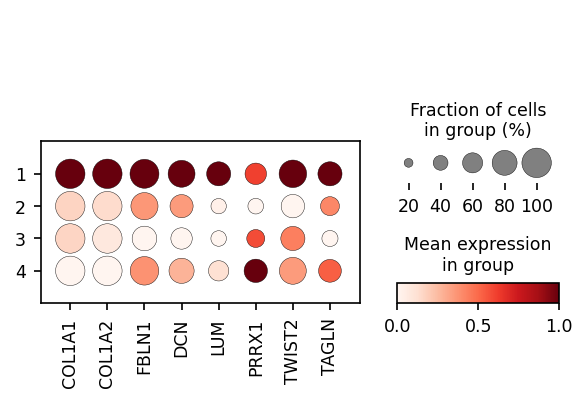

In [28]:
vars_to_plot = [
    'COL1A1', 'COL1A2', 'FBLN1', 'DCN', 'LUM', 'PRRX1', 'TWIST2', 'TAGLN',
]

vars_to_plot = [g for g in vars_to_plot if g in adata7.var_names]

sc.pl.dotplot(
    adata7,
    var_names=vars_to_plot,
    groupby='cluster_str',
    standard_scale='var',
    layer='log_norm',
)

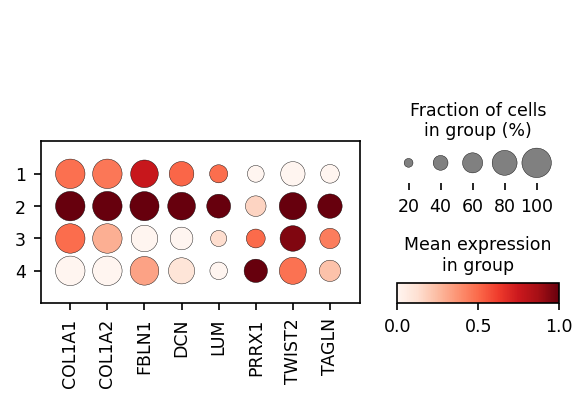

In [29]:
vars_to_plot = [
    'COL1A1', 'COL1A2', 'FBLN1', 'DCN', 'LUM', 'PRRX1', 'TWIST2', 'TAGLN',
]

vars_to_plot = [g for g in vars_to_plot if g in adata21.var_names]

sc.pl.dotplot(
    adata21,
    var_names=vars_to_plot,
    groupby='cluster_str',
    standard_scale='var',
    layer='log_norm',
)